# 17 -- Typing triplet-loss embedder (v1)

Same structure as `14_gesture_embedder.ipynb` / `15_tap_embedder.ipynb` /
`16_motion_embedder.ipynb` (fixed-identity-set AUC-vs-k, negative control,
multi-seed stability, permutation feature importance, checkpoint caching),
retargeted to the typing modality.

**Baseline note**: `BASELINE_AUC` is loaded directly from
`trust_window_results.csv` at runtime (typing / `fixed_across_k` rows),
same as nb16, not hand-copied.

**Volume warning -- read before treating any "no fixed set" output as a
bug**: `typing_windows.parquet` has 646 windows total (per the last
confirmed export), vs. ~3,100-3,200 for tap/gesture/motion -- roughly a
fifth as much data. This may genuinely not support the k=20
fixed-identity evaluation at all (too few identities with >=20 probe
windows to form a usable fixed set), and separately may leave too few
train-role windows per identity for the batch sampler to find eligible
identities (needs >=4 per identity per batch). Both notebook-level and
harness-level code already handle this gracefully (falls back to
`all_available` with a printed warning; `evaluate_trust_windows.py`
already skips a modality if fewer than 2 fixed identities qualify) -- a
sparse or partially-skipped result here is an expected, reportable
finding about typing specifically, not something to force by lowering k
or loosening thresholds just to get a headline number.


In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.decomposition import PCA

%config InlineBackend.close_figures = False

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
typing_path = find(str(MOD_DIR / 'typing_windows.parquet'), 'typing_windows.parquet',
                    '/mnt/user-data/uploads/typing_windows.parquet')
splits_path = find(str(MOD_DIR / 'identity_splits.csv'), 'identity_splits.csv',
                    '/mnt/user-data/uploads/identity_splits.csv')

# OUT_DIR is derived directly from MOD_DIR's parent (data/processed/), NOT
# discovered via find() -- see nb15/nb16 session notes for why (a shared
# fallback dir with unprefixed filenames silently overwrote one
# modality's output with another's).
OUT_DIR = MOD_DIR.parent / 'typing_embedder'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)
CKPT_DIR = OUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)
print(f"Outputs will be written to: {OUT_DIR.resolve()}")

df = pd.read_parquet(typing_path)
splits = pd.read_csv(splits_path)
df = df.merge(splits[['sessionId', 'role']], on='sessionId', how='inner')
print(f"typing windows: {df.shape}, sessions matched to splits: {df['sessionId'].nunique()}")
print(df.groupby('role').size())


Outputs will be written to: /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/typing_embedder
typing windows: (684, 169), sessions matched to splits: 82
role
enrol     72
probe     60
train    552
dtype: int64


## 1. Feature preparation

In [2]:
ID = {'sessionId','participantId','deviceFamily','window_index','window_start_s','window_end_s',
      'taskIndex','taskType','activeArea','task_pass','task_start_s','task_end_s','role'}

feats = [c for c in df.columns if c not in ID and pd.api.types.is_numeric_dtype(df[c])]
coverage = df[feats].notna().mean()
feats = coverage[coverage >= 0.5].index.tolist()
print(f"{len(feats)} features used")

train_df = df[df['role'] == 'train']
imputer = SimpleImputer(strategy='median').fit(train_df[feats])
scaler = StandardScaler().fit(imputer.transform(train_df[feats]))

def embed_input(sub):
    return scaler.transform(imputer.transform(sub[feats])).astype(np.float32)

X_all = embed_input(df)
y_all = df['participantId'].values
role_all = df['role'].values
print(f"X_all: {X_all.shape}")

def data_fingerprint():
    h = hashlib.sha256()
    h.update(X_all.tobytes()); h.update(str(sorted(feats)).encode())
    h.update(role_all.tobytes() if role_all.dtype.kind in 'iuf' else str(list(role_all)).encode())
    return h.hexdigest()[:16]

110 features used
X_all: (684, 110)


## 2. Batch composition check

participantId
pCURDWC      1
pG2C8BC      2
pEAB9GS      3
pW49U3Q      4
pUNKH7L      4
pG5G4MS      5
pEZVKTS      9
pA6XL23      9
pCTJ44P     11
pZMC82M     23
pWJGKPK     34
pAFQRTM     44
pNDG8LJ     44
p3M6E7Z     59
p3YDMHG     79
p95MPVX    109
pH3S4X4    112


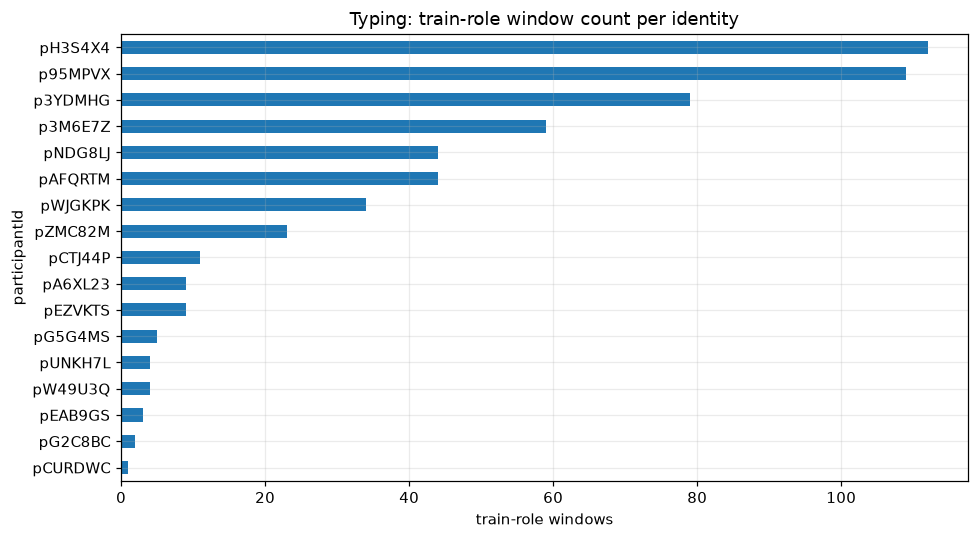


17 identities have train-role data, minimum 1 windows.
NOTE: at least one identity is below the batch sampler's per-identity minimum (4 windows) -- expected given typing's smaller total window count, not a bug. That identity will simply be ineligible for training batches (see Section 3).


In [3]:
train_counts = df[df['role']=='train'].groupby('participantId').size().sort_values()
print(train_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
train_counts.plot(kind='barh', ax=ax)
ax.set_xlabel('train-role windows'); ax.set_title('Typing: train-role window count per identity')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '01_train_windows_per_identity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{len(train_counts)} identities have train-role data, minimum {train_counts.min()} windows.")
if train_counts.min() < 4:
    print("NOTE: at least one identity is below the batch sampler's per-identity minimum "
          "(4 windows) -- expected given typing's smaller total window count, not a bug. "
          "That identity will simply be ineligible for training batches (see Section 3).")


## 3. Batch sampler and model

Architecture unchanged from the gesture notebook (P1's 256-128-32 MLP,
dropout 0.10, L2-normalised output, batch-all triplet loss, margin 0.20).
Same capped-batches-per-epoch speed fix and checkpoint cache as nb14.

In [4]:
IDENTITIES_PER_BATCH = 2
WINDOWS_PER_IDENTITY = 4
MARGIN = 0.20
EMBED_DIM = 32
EPOCHS = 40
LR = 1e-4
WEIGHT_DECAY = 1e-4
MAX_BATCHES_PER_EPOCH = 150

class BalancedIdentityBatchSampler(torch.utils.data.Sampler):
    def __init__(self, labels, identities_per_batch, windows_per_identity,
                 max_batches=MAX_BATCHES_PER_EPOCH, seed=0):
        self.by_identity = {pid: np.where(labels == pid)[0] for pid in np.unique(labels)}
        self.eligible = [pid for pid, idx in self.by_identity.items()
                          if len(idx) >= windows_per_identity]
        self.k, self.m = identities_per_batch, windows_per_identity
        self.rng = np.random.default_rng(seed)
        natural = max(1, sum(len(v) for v in self.by_identity.values()) // (self.k * self.m))
        self.n_batches = min(natural, max_batches)

    def __iter__(self):
        for _ in range(self.n_batches):
            pids = self.rng.choice(self.eligible, size=self.k, replace=False)
            batch = []
            for pid in pids:
                idx = self.by_identity[pid]
                chosen = self.rng.choice(idx, size=self.m, replace=len(idx) < self.m)
                batch.extend(chosen.tolist())
            yield batch

    def __len__(self):
        return self.n_batches


class Embedder(nn.Module):
    def __init__(self, in_dim, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, embed_dim),
        )
    def forward(self, x):
        return nn.functional.normalize(self.net(x), p=2, dim=1)


def batch_all_triplet_loss(embeddings, labels, margin=MARGIN):
    dist = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.unsqueeze(0)
    same = (labels == labels.T)
    eye = torch.eye(len(labels[0]), dtype=torch.bool, device=embeddings.device)
    pos_mask, diff = same & ~eye, ~same

    losses = []
    for a in range(len(embeddings)):
        pos_d, neg_d = dist[a][pos_mask[a]], dist[a][diff[a]]
        if len(pos_d) == 0 or len(neg_d) == 0:
            continue
        l = torch.clamp(pos_d.unsqueeze(1) - neg_d.unsqueeze(0) + margin, min=0)
        losses.append(l.flatten())
    if not losses:
        return torch.tensor(0.0, requires_grad=True), 0.0
    all_losses = torch.cat(losses)
    active = all_losses[all_losses > 0]
    return all_losses.mean(), (active.numel() / max(all_losses.numel(), 1))

print(f"input dim {len(feats)}, embedding dim {EMBED_DIM}, "
      f"up to {MAX_BATCHES_PER_EPOCH} batches/epoch")

input dim 110, embedding dim 32, up to 150 batches/epoch


## 4. Training, with a checkpoint cache

Same `FORCE_RETRAIN = False` cache-by-data-fingerprint pattern as nb14.

In [5]:
FORCE_RETRAIN = True

def train_embedder(X, y, role, seed=0, epochs=EPOCHS, verbose=True):
    torch.manual_seed(seed)
    train_mask = role == 'train'
    X_train, y_train = X[train_mask], y[train_mask]
    model = Embedder(X.shape[1], EMBED_DIM)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sampler = BalancedIdentityBatchSampler(y_train, IDENTITIES_PER_BATCH, WINDOWS_PER_IDENTITY, seed=seed)
    history = {'epoch': [], 'loss': [], 'active_frac': []}
    for epoch in range(epochs):
        model.train()
        epoch_losses, epoch_actives = [], []
        for batch_idx in sampler:
            xb = torch.tensor(X_train[batch_idx])
            yb = torch.tensor(pd.factorize(y_train[batch_idx])[0])
            opt.zero_grad()
            emb = model(xb)
            loss, active_frac = batch_all_triplet_loss(emb, yb)
            loss.backward(); opt.step()
            epoch_losses.append(loss.item()); epoch_actives.append(active_frac)
        history['epoch'].append(epoch)
        history['loss'].append(np.mean(epoch_losses))
        history['active_frac'].append(np.mean(epoch_actives))
        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:2d}  loss={history['loss'][-1]:.4f}  active_frac={history['active_frac'][-1]:.3f}")
    return model, pd.DataFrame(history)

fp = data_fingerprint()
ckpt_path = CKPT_DIR / f'primary_seed42_{fp}.pt'
if ckpt_path.exists() and not FORCE_RETRAIN:
    print(f"Loading cached model (fingerprint {fp}) -- set FORCE_RETRAIN=True to retrain.")
    ckpt = torch.load(ckpt_path, weights_only=False)
    model = Embedder(len(feats), EMBED_DIM)
    model.load_state_dict(ckpt['state_dict'])
    history = ckpt['history']
else:
    print("Training real-label model (seed=42)...")
    model, history = train_embedder(X_all, y_all, role_all, seed=42)
    torch.save({'state_dict': model.state_dict(), 'history': history}, ckpt_path)
    print(f"Cached to {ckpt_path.name}")

Training real-label model (seed=42)...
  epoch  0  loss=0.1630  active_frac=0.641
  epoch  5  loss=0.0980  active_frac=0.465
  epoch 10  loss=0.0481  active_frac=0.258
  epoch 15  loss=0.0695  active_frac=0.330
  epoch 20  loss=0.0677  active_frac=0.338
  epoch 25  loss=0.0737  active_frac=0.363
  epoch 30  loss=0.0414  active_frac=0.209
  epoch 35  loss=0.0385  active_frac=0.188
  epoch 39  loss=0.0370  active_frac=0.177
Cached to primary_seed42_bc498d1cb88471b7.pt


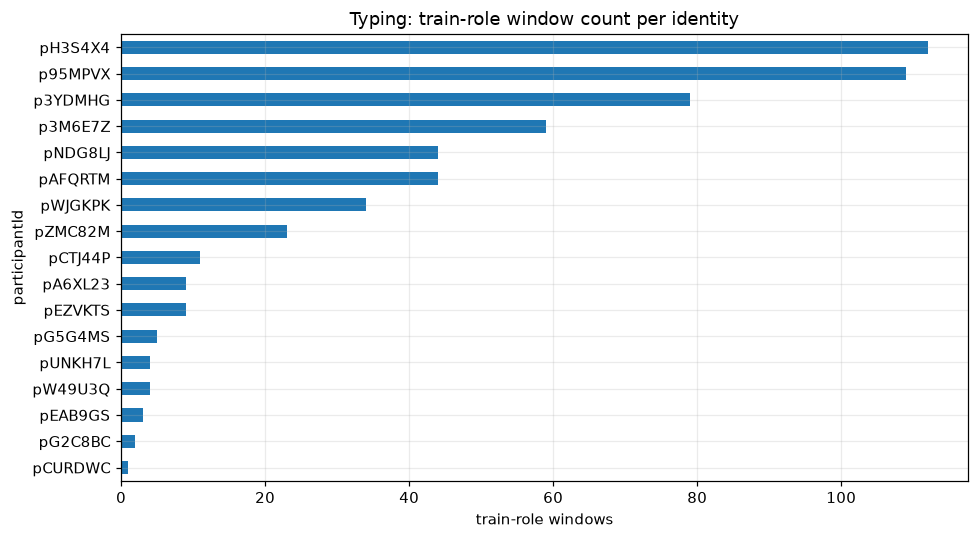

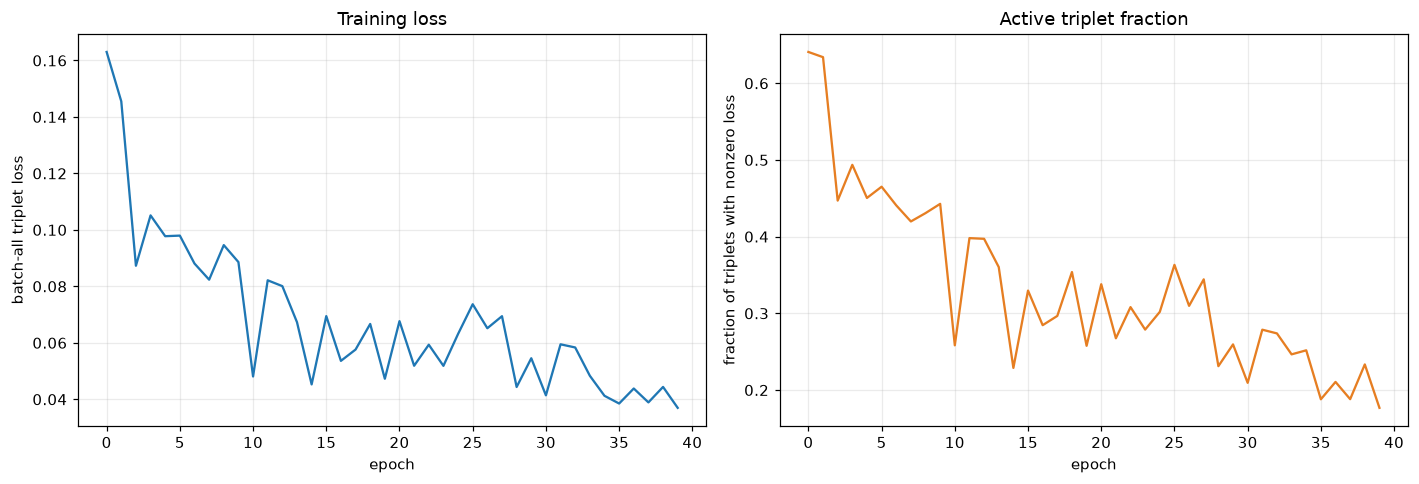

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history['epoch'], history['loss'])
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('batch-all triplet loss'); axes[0].set_title('Training loss')
axes[1].plot(history['epoch'], history['active_frac'], color='#e67e22')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('fraction of triplets with nonzero loss')
axes[1].set_title('Active triplet fraction')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '02_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluation -- fixed identity set

Same fixed-vs-all-available identity-set split as nb14, to avoid the
survivorship confound where the probe-identity set shrinks as k grows.

In [7]:
def compute_metrics(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return {'auc': np.nan, 'eer': np.nan, 'far_at_10pct_frr': np.nan}
    auc = roc_auc_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    frr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fpr - frr)))
    eer = float((fpr[idx] + frr[idx]) / 2)
    far10 = float(np.interp(0.90, tpr, fpr))
    return {'auc': float(auc), 'eer': eer, 'far_at_10pct_frr': far10}

def embed(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X)).numpy()

def score_probe_windows(E, y, df_meta, role, k_values):
    """Long-form scored rows: one per (k, probe_pid, candidate, trust-window
    instance). trust_id lets cohort normalisation and per-identity breakdown
    both work off the same table. Each trust window also carries its actual
    elapsed wall-clock span (span_s = end of its last window minus start of
    its first), computed from real window_start_s/window_end_s rather than
    assumed from k and a window-length/stride constant -- the same approach
    evaluate_trust_windows.py's build_trust_windows() uses, and deliberately
    so: the window-length/stride decision for P2's pipeline is still
    unresolved, so nothing here should assume a specific value for either."""
    enrol_mask, probe_mask = role == 'enrol', role == 'probe'
    refs = {pid: E[enrol_mask & (y == pid)].mean(axis=0) for pid in np.unique(y[enrol_mask])}
    rows = []
    for pid in np.unique(y[probe_mask]):
        idx = np.where(probe_mask & (y == pid))[0]
        order = np.argsort(df_meta.loc[idx, 'window_start_s'].values)
        idx_ordered = idx[order]
        Ep = E[idx_ordered]
        starts = df_meta.loc[idx_ordered, 'window_start_s'].values
        ends = df_meta.loc[idx_ordered, 'window_end_s'].values
        for k in k_values:
            if len(Ep) < k: continue
            for i in range(len(Ep) - k + 1):
                agg = Ep[i:i+k].mean(axis=0)
                span_s = float(ends[i + k - 1] - starts[i])
                for cand, ref in refs.items():
                    rows.append({'k': k, 'pid': pid, 'cand': cand, 'genuine': int(cand == pid),
                                 'dist': float(np.linalg.norm(agg - ref)),
                                 'trust_id': f'{pid}|{i}|{k}', 'span_s': span_s})
    return pd.DataFrame(rows), refs

def summarise(scored, fixed_identities=None, label=''):
    """Cohort-normalised AUC/EER/FAR@10%FRR per k (and per identity),
    optionally restricted to a fixed identity set. median_span_s reports
    each k's actual elapsed wall-clock time (median across trust windows,
    empirical -- see score_probe_windows docstring), a cheap way to read
    the AUC-vs-k curve as a detection-latency curve without assuming a
    window-length/stride value that hasn't been decided yet. Per-identity
    rows now also carry EER, not just AUC -- diagnostic colour for
    flagging outliers alongside the leave-one-out check, not a headline
    number (per-single-identity EER is the most extreme version of the
    small-N instability this project has spent real time diagnosing --
    read it with the same caution as any low-comparison-count result)."""
    if fixed_identities is not None:
        scored = scored[scored['pid'].isin(fixed_identities)]
    per_k, per_identity = [], []
    for k, g in scored.groupby('k'):
        g = g.copy()
        g['z'] = g.groupby('trust_id')['dist'].transform(
            lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
        median_span_s = g.drop_duplicates('trust_id')['span_s'].median()
        per_k.append({'k': k, 'identity_set': label, 'n_probe_identities': g['pid'].nunique(),
                       'n_trust_windows': g['trust_id'].nunique(), 'median_span_s': median_span_s,
                       **compute_metrics(g['genuine'], -g['z'])})
        for pid, gp in g.groupby('pid'):
            if gp['genuine'].nunique() < 2: continue
            pid_metrics = compute_metrics(gp['genuine'], -gp['z'])
            per_identity.append({'k': k, 'identity_set': label, 'participantId': pid,
                                  'auc': pid_metrics['auc'], 'eer': pid_metrics['eer'],
                                  'n_comparisons': len(gp)})
    return pd.DataFrame(per_k), pd.DataFrame(per_identity)

k_values = [1, 2, 3, 5, 8, 10, 15, 20]
E_all = embed(model, X_all)
df_idx = df.reset_index(drop=True)
scored, refs = score_probe_windows(E_all, y_all, df_idx, role_all, k_values)
print(f"{len(refs)} reference identities, {len(scored)} scored rows")

res_all, per_id_all = summarise(scored, fixed_identities=None, label='all_available')

max_k = max(k_values)
probe_counts = df_idx[df_idx['role']=='probe'].groupby('participantId').size()
fixed_identities = set(probe_counts[probe_counts >= max_k].index) & set(refs.keys())
print(f"{len(fixed_identities)} identities have >= {max_k} probe windows: {sorted(fixed_identities)}")

if len(fixed_identities) >= 2:
    res_fixed, per_id_fixed = summarise(scored, fixed_identities=fixed_identities, label='fixed_across_k')
    res_df = pd.concat([res_all, res_fixed], ignore_index=True)
    per_id_df = pd.concat([per_id_all, per_id_fixed], ignore_index=True)
else:
    # Do NOT append a duplicate copy of res_all/per_id_all here. An earlier
    # version did (`res_fixed, per_id_fixed = res_all.copy(), ...`), but
    # that copy's identity_set column still read 'all_available' rather
    # than being relabeled -- concatenating it onto res_all silently
    # duplicated every row. Went unnoticed because every prior consumer
    # filtered specifically on identity_set=='fixed_across_k' (empty in
    # this branch, so nothing showed); Section 6's elapsed-time table was
    # the first thing to display whatever label IS present, which is what
    # surfaced it on typing. Leaving res_df/per_id_df as exactly res_all/
    # per_id_all (no fixed_across_k rows at all) is both correct and
    # already what every downstream .empty / .any() check expects.
    print("WARNING: fewer than 2 identities qualify for the fixed set -- reporting all_available only.")
    res_df = res_all.copy()
    per_id_df = per_id_all.copy()

print()
print(res_df[res_df['identity_set']=='fixed_across_k']
      [['k','n_probe_identities','median_span_s','auc','eer']].to_string(index=False, float_format=lambda v:f'{v:.3f}'))

11 reference identities, 2772 scored rows
1 identities have >= 20 probe windows: ['p3M6E7Z']

Empty DataFrame
Columns: [k, n_probe_identities, median_span_s, auc, eer]
Index: []


## 5b. Leave-one-out dominance check

Mirrors `evaluate_trust_windows.py`'s leave-one-out logic. Recomputes
cohort-normalised AUC with each fixed-set identity held out in turn -- a
single identity dominating (or dragging down) the pooled number would
otherwise only be visible by manually scanning `per_identity` output.
Run at k=20 (the headline k) on the fixed identity set -- if the fixed
set has very few members here (see the volume warning in Section 0),
treat this check's output with proportionally more caution, the same way
P1 flagged its own n=2 desktop evaluation as unstable rather than
reporting the mean alone.


In [8]:
def leave_one_out_auc(scored, fixed_identities, k):
    base = scored[(scored['k']==k) & scored['pid'].isin(fixed_identities)]
    results = {}
    for pid_out in sorted(fixed_identities):
        sub = base[base['pid'] != pid_out].copy()
        if sub['genuine'].nunique() < 2:
            continue
        sub['z'] = sub.groupby('trust_id')['dist'].transform(
            lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
        results[pid_out] = roc_auc_score(sub['genuine'], -sub['z'])
    return results

# LOO_K was hardcoded to 20 in nb14/15/16. That's safe there because tap/
# gesture/motion always have a fixed_across_k row at k=20. Typing's much
# smaller window count means that's not guaranteed -- confirmed: running
# this unchanged raised IndexError from an empty .iloc[0] lookup when no
# fixed_across_k row exists at k=20. Fix: pick the LARGEST k that actually
# has a fixed_across_k row, rather than assuming 20, and skip this section
# entirely (rather than crash) if there's no fixed_across_k row at any k.
_fixed_rows = res_df[res_df['identity_set']=='fixed_across_k']
if _fixed_rows.empty or len(fixed_identities) < 2:
    print("Skipping leave-one-out check: no fixed_across_k identity set was evaluable for "
          "typing (see Section 5's warning above) -- there's nothing to hold identities out "
          "of. This is expected given typing's window count, not a bug.")
    loo, loo_df = {}, pd.DataFrame(columns=['identity_removed', 'auc_without_them', 'shift_from_full'])
else:
    LOO_K = int(_fixed_rows['k'].max())
    if LOO_K != 20:
        print(f"NOTE: using LOO_K={LOO_K} instead of the usual 20 -- typing's fixed identity "
              f"set doesn't reach k=20 (see Section 5 warning). Reported at the largest k that "
              f"IS evaluable on the fixed set, not the usual headline k -- keep that in mind "
              f"when comparing this number against tap/gesture/motion's k=20 figures.")
    loo = leave_one_out_auc(scored, fixed_identities, LOO_K)
    full_auc = _fixed_rows[_fixed_rows['k']==LOO_K]['auc'].iloc[0]

    loo_df = pd.DataFrame(sorted(loo.items(), key=lambda kv: kv[1]),
                           columns=['identity_removed', 'auc_without_them'])
    loo_df['shift_from_full'] = loo_df['auc_without_them'] - full_auc
    print(f"Full fixed-set AUC at k={LOO_K}: {full_auc:.3f}\n")
    print(loo_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

    if len(loo_df):
        worst_shift = loo_df['shift_from_full'].abs().max()
        if worst_shift > 0.03:
            dominant = loo_df.loc[loo_df['shift_from_full'].abs().idxmax(), 'identity_removed']
            print(f"\nFLAG: removing {dominant} shifts pooled AUC by "
                  f"{loo_df['shift_from_full'].abs().max():+.3f} -- check that identity's "
                  f"per-participant AUC directly before treating the pooled k={LOO_K} number as representative.")


Skipping leave-one-out check: no fixed_across_k identity set was evaluable for typing (see Section 5's warning above) -- there's nothing to hold identities out of. This is expected given typing's window count, not a bug.


## 6. Trained embedder vs raw-distance baseline

`BASELINE_AUC` is loaded directly from `trust_window_results.csv` at
runtime (typing / `fixed_across_k` / `auc_cohort_norm` rows) rather
than hand-copied into a dict, which avoids the stale-baseline problem an
earlier version of this notebook hit when a hand-copied dict fell out of
sync with a refreshed harness run. If this cell prints a "no rows found"
warning, re-run `evaluate_trust_windows.py` first -- the overlay just
won't show baseline points until that file has typing rows in it.


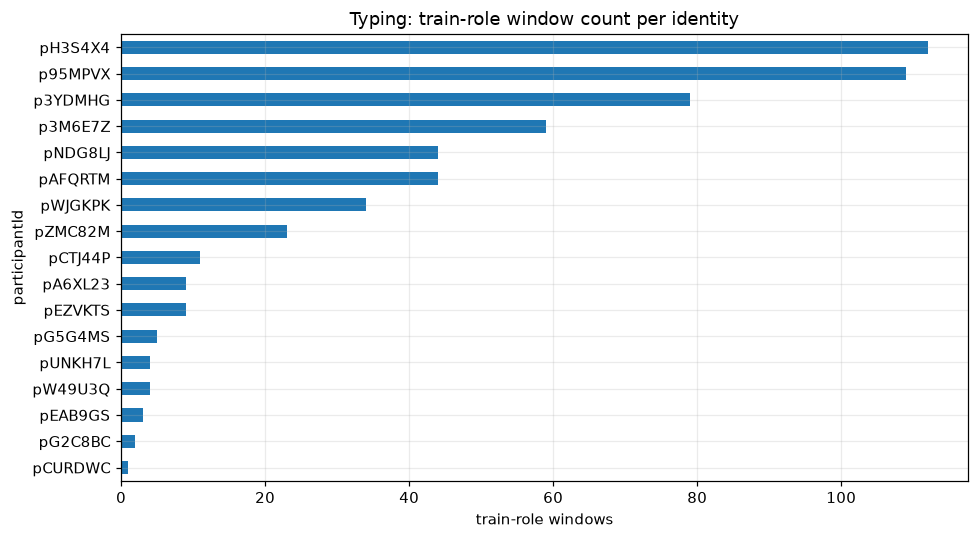

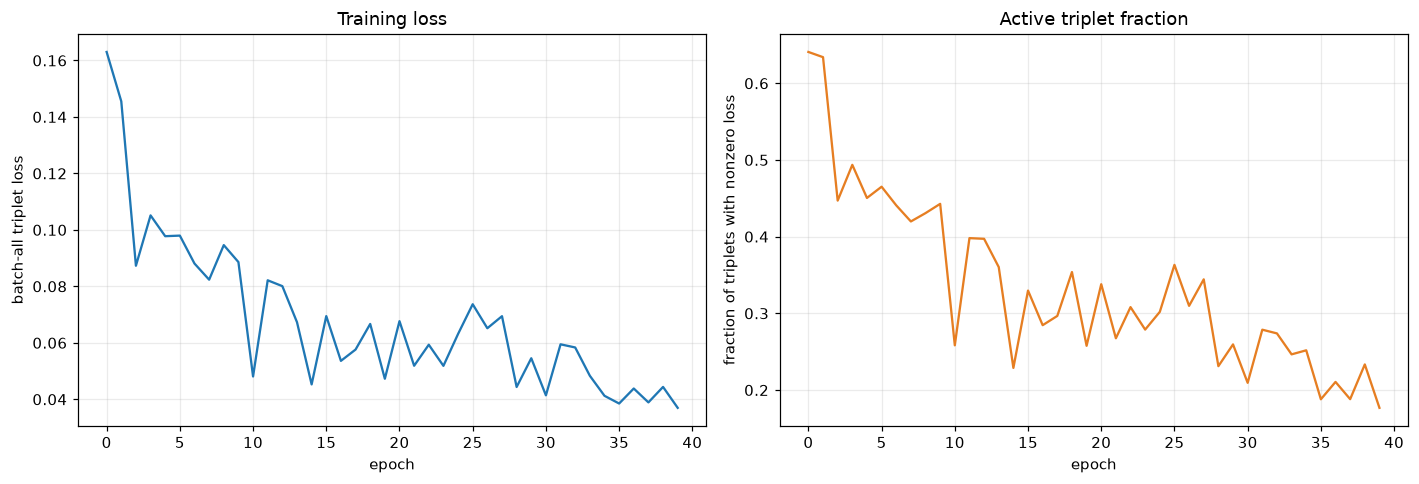

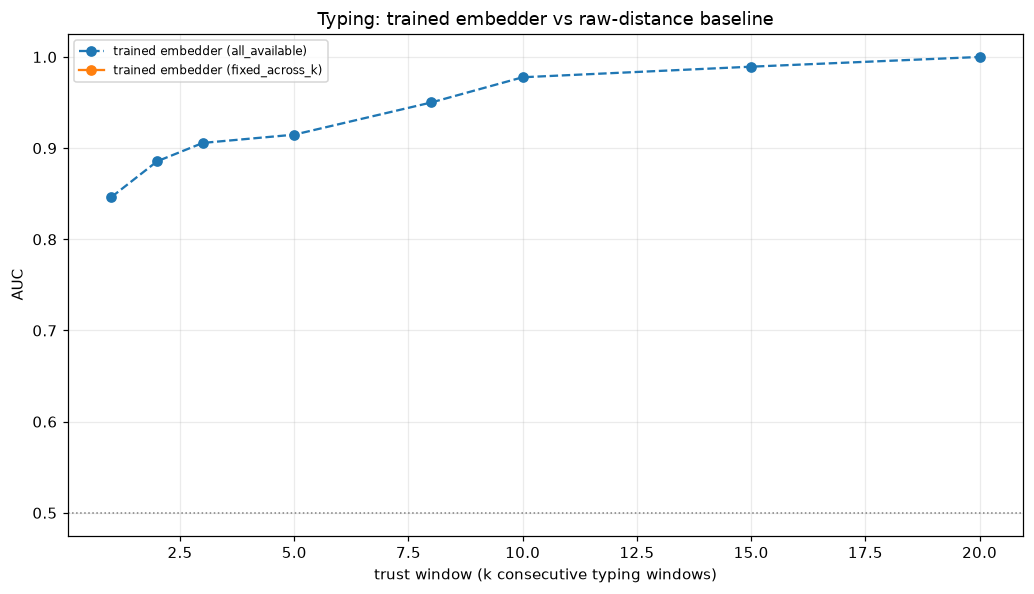


k -> elapsed time (median across trust windows, all_available identity set):
 k  median_span_s  auc
 1           15.0  0.8
 2           22.5  0.9
 3           30.0  0.9
 5           45.0  0.9
 8           67.5  1.0
10           82.5  1.0
15          120.0  1.0
20          221.3  1.0

k=20 not evaluable on the fixed set.


In [9]:
trust_results_path = find(str(MOD_DIR / 'trust_window_results.csv'),
                           'trust_window_results.csv',
                           '/mnt/user-data/uploads/trust_window_results.csv')
_trust_df = pd.read_csv(trust_results_path)
_baseline_rows = _trust_df[(_trust_df['modality']=='typing') & (_trust_df['identity_set']=='fixed_across_k')]
BASELINE_AUC = dict(zip(_baseline_rows['k_windows'], _baseline_rows['auc_cohort_norm']))
if not BASELINE_AUC:
    print("WARNING: no typing/fixed_across_k rows found in trust_window_results.csv -- "
          "either re-run evaluate_trust_windows.py, or this modality was skipped there entirely "
          "for having fewer than 2 fixed identities. The overlay below will just be empty in that case.")
else:
    print(f"Loaded baseline AUC for k={sorted(BASELINE_AUC.keys())} from {trust_results_path}")

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, style in [('all_available', '--'), ('fixed_across_k', '-')]:
    sub = res_df[res_df['identity_set']==label].sort_values('k')
    ax.plot(sub['k'], sub['auc'], marker='o', ls=style, label=f'trained embedder ({label})')
bl_k = [k for k in k_values if k in BASELINE_AUC]
if bl_k:
    ax.plot(bl_k, [BASELINE_AUC[k] for k in bl_k], marker='s', ls=':', color='gray',
            label='raw-distance baseline (fixed set, cohort-normalised, from harness)')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('trust window (k consecutive typing windows)'); ax.set_ylabel('AUC')
ax.set_title('Typing: trained embedder vs raw-distance baseline')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '03_embedder_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Elapsed-time reading of the same k-axis, using each k's ACTUAL median
# wall-clock span (see score_probe_windows docstring) rather than an
# assumed window-length/stride constant -- that decision is still
# unresolved for P2's pipeline (see subsec:p2-pipeline), so nothing here
# should presume a value. This is the same curve as above, just read as
# "AUC after N seconds of observation" instead of "AUC after k windows".
_span_label = 'fixed_across_k' if (res_df['identity_set']=='fixed_across_k').any() else 'all_available'
_span_table = res_df[res_df['identity_set']==_span_label][['k', 'median_span_s', 'auc']].sort_values('k')
print(f"\nk -> elapsed time (median across trust windows, {_span_label} identity set):")
print(_span_table.to_string(index=False, float_format=lambda v: f'{v:.1f}'))

drop_at_20 = (res_df[(res_df['identity_set']=='all_available')&(res_df['k']==20)]['auc'].iloc[0] -
              res_df[(res_df['identity_set']=='fixed_across_k')&(res_df['k']==20)]['auc'].iloc[0]) \
             if ((res_df['identity_set']=='fixed_across_k')&(res_df['k']==20)).any() else float('nan')
print(f"\nAUC at k=20, all_available minus fixed_across_k: {drop_at_20:+.3f} "
      f"(positive means the earlier, unfixed curve was inflated by identity dropout)"
      if drop_at_20 == drop_at_20 else "\nk=20 not evaluable on the fixed set.")

for k in bl_k:
    trained = res_df[(res_df['identity_set']=='fixed_across_k')&(res_df['k']==k)]['auc']
    if len(trained):
        print(f"k={k:2d}: embedder {trained.iloc[0]:.3f} vs baseline {BASELINE_AUC[k]:.3f} "
              f"({trained.iloc[0]-BASELINE_AUC[k]:+.3f})")


## 7. Multi-seed stability (fixed identity set)

In [10]:
SEEDS = [7, 13, 42]
seed_results = []
for seed in SEEDS:
    print(f"seed {seed}...")
    ckpt_s = CKPT_DIR / f'seed{seed}_{fp}.pt'
    if ckpt_s.exists() and not FORCE_RETRAIN:
        m = Embedder(len(feats), EMBED_DIM)
        m.load_state_dict(torch.load(ckpt_s, weights_only=False)['state_dict'])
    else:
        m, _ = train_embedder(X_all, y_all, role_all, seed=seed, verbose=False)
        torch.save({'state_dict': m.state_dict()}, ckpt_s)
    Es = embed(m, X_all)
    sc, _ = score_probe_windows(Es, y_all, df_idx, role_all, [1, 10, 20])
    rk, _ = summarise(sc, fixed_identities=fixed_identities, label='fixed_across_k')
    rk['seed'] = seed
    seed_results.append(rk)

seed_df = pd.concat(seed_results, ignore_index=True)
summary = seed_df.groupby('k')['auc'].agg(['mean', 'std'])
print(summary.round(3).to_string())

seed 7...
seed 13...
seed 42...
     mean    std
k               
1   0.849  0.009
10  0.989  0.011
20  1.000  0.000


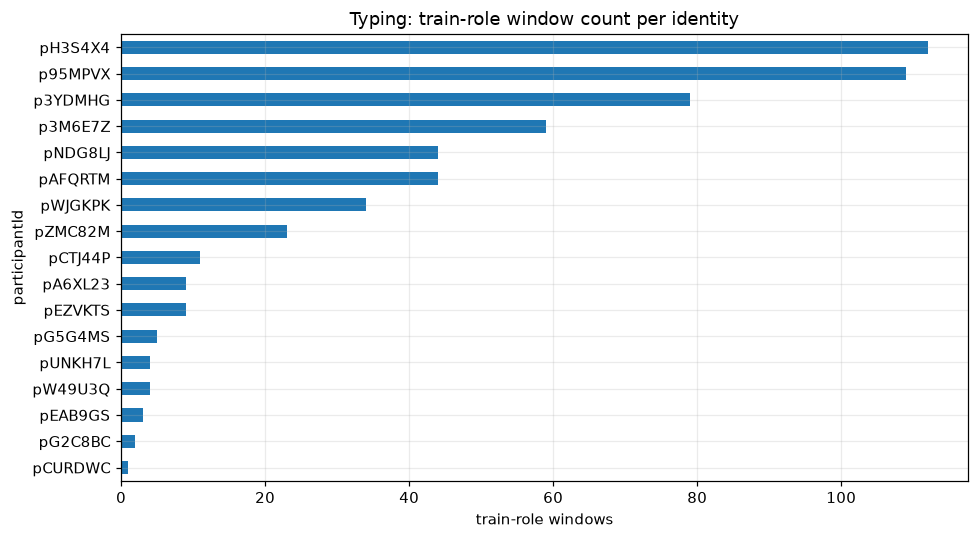

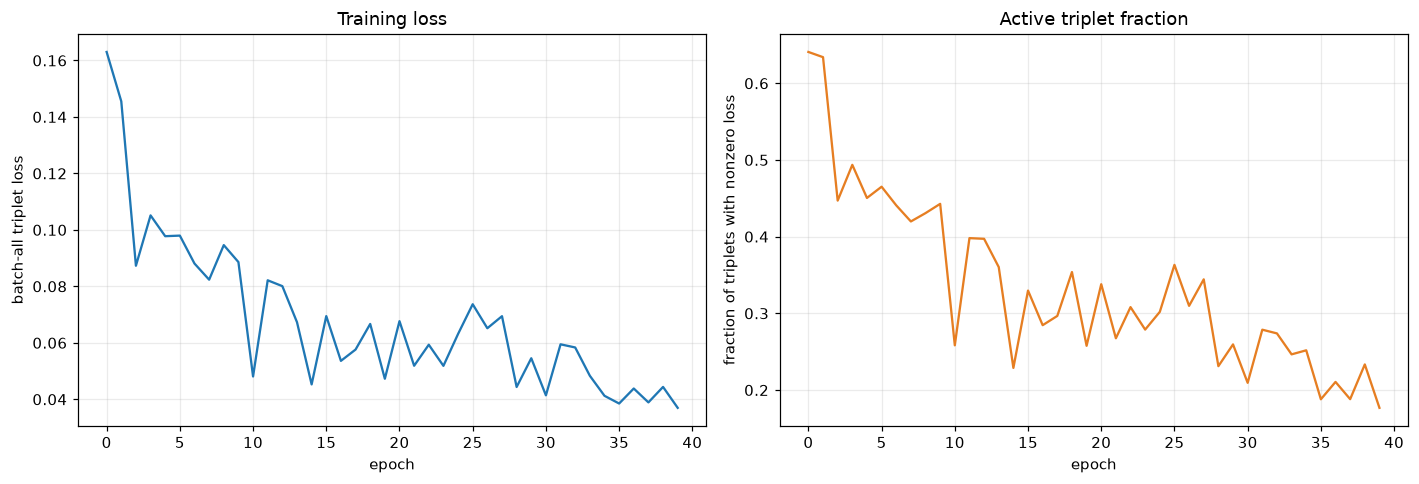

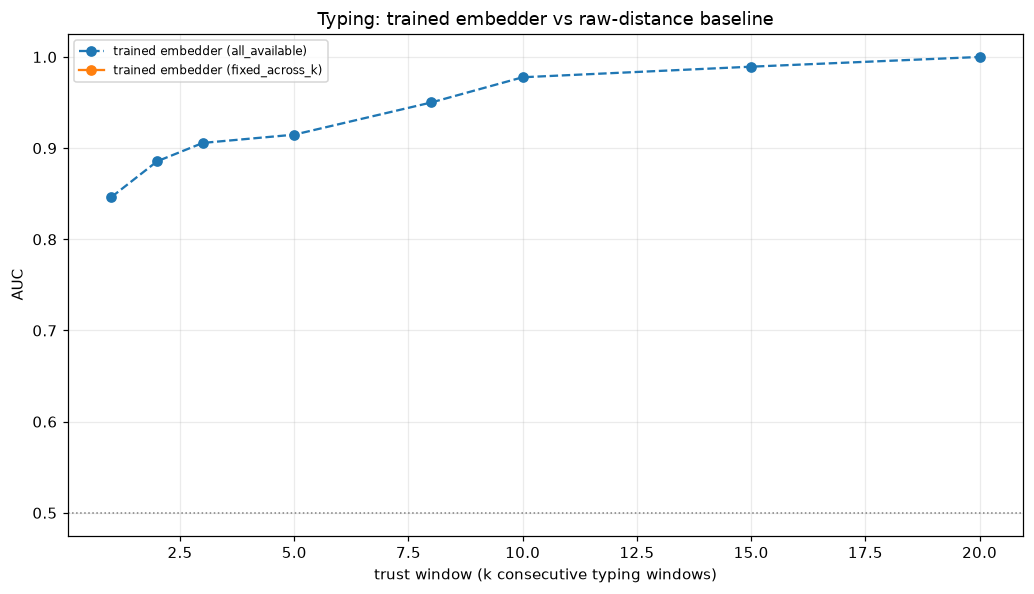

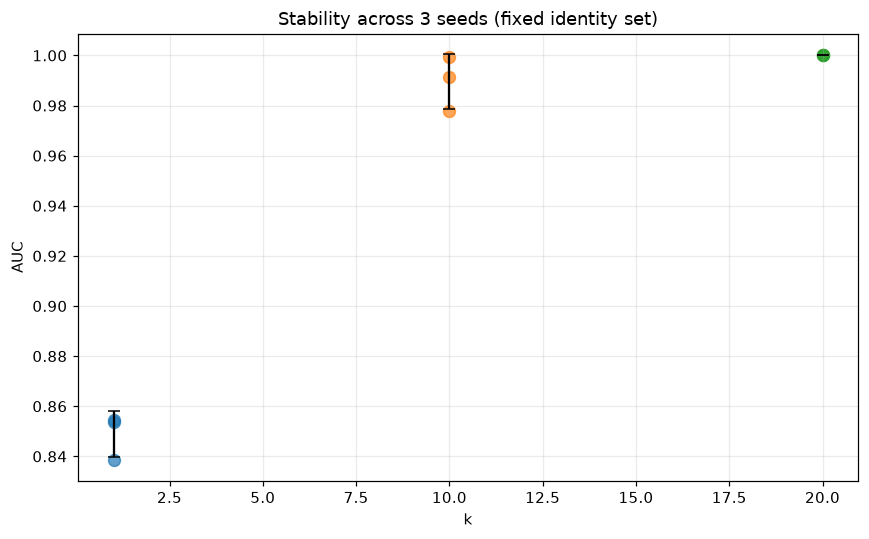

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
for k in seed_df['k'].unique():
    vals = seed_df[seed_df['k']==k]['auc']
    ax.scatter([k]*len(vals), vals, alpha=0.7, s=60)
ax.errorbar(summary.index, summary['mean'], yerr=summary['std'], fmt='none', color='k', capsize=4)
ax.set_xlabel('k'); ax.set_ylabel('AUC'); ax.set_title(f'Stability across {len(SEEDS)} seeds (fixed identity set)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '04_seed_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Negative control -- trained model, fixed identity set

In [12]:
def compute_fixed_identities(y, role, refs, k_values):
    max_k = max(k_values)
    probe_mask = role == 'probe'
    probe_counts = pd.Series(y[probe_mask]).value_counts()
    return set(probe_counts[probe_counts >= max_k].index) & set(refs.keys())

def shuffle_labels(y, df_meta, seed):
    rng = np.random.default_rng(seed)
    sess_pid = df_meta.groupby('sessionId')['participantId'].first()
    mapping = dict(zip(sess_pid.index, rng.permutation(sess_pid.values)))
    return df_meta['sessionId'].map(mapping).values

def filter_leaked_identities(y_shuf, role, fixed_ids, df_meta):
    # Drops any shuffled fake identity where ANY real participant appears
    # in both its enrol and probe windows (not just the dominant one).
    # On tap (nb15) and motion (nb16), this and a device-family confound
    # (mobile vs desktop) were both confirmed as ruled out for the residual
    # per-seed AUC spread -- what's left after this filter is small-N noise,
    # not leakage. Typing's total window count is far smaller than either,
    # so expect this effect to be MORE pronounced here, not less -- possibly
    # down to 0 clean identities in some seeds. That's a data-volume finding
    # about typing, not evidence the filter itself has stopped working.
    enrol_mask, probe_mask = role == 'enrol', role == 'probe'
    clean, dropped = set(), []
    for fake_pid in fixed_ids:
        e_true = set(df_meta.loc[enrol_mask & (y_shuf == fake_pid), 'participantId'])
        p_true = set(df_meta.loc[probe_mask & (y_shuf == fake_pid), 'participantId'])
        if not e_true or not p_true:
            continue
        overlap = e_true & p_true
        if overlap:
            dropped.append((fake_pid, sorted(overlap)))
            continue
        clean.add(fake_pid)
    return clean, dropped

CONTROL_K_VALUES = [1, 10, 20]
SEEDS_CONTROL = list(range(8))  # widened from [0,1,2] -- with as few as 1-3
# clean identities surviving the leakage filter in some seeds, AUC over so
# few identities is inherently noisy (same small-N instability documented
# for P1's n=2 desktop evaluation); more seeds are needed to separate a
# real residual effect from an unlucky draw. Report mean/std across all
# seeds rather than treating any single seed as definitive.
control_results = []
control_fixed_id_counts = []
for seed in SEEDS_CONTROL:
    y_shuf = shuffle_labels(y_all, df_idx, seed)
    ckpt_c = CKPT_DIR / f'control{seed}_{fp}.pt'
    if ckpt_c.exists() and not FORCE_RETRAIN:
        m = Embedder(len(feats), EMBED_DIM)
        m.load_state_dict(torch.load(ckpt_c, weights_only=False)['state_dict'])
    else:
        m, _ = train_embedder(X_all, y_shuf, role_all, seed=seed, verbose=False)
        torch.save({'state_dict': m.state_dict()}, ckpt_c)
    Ec = embed(m, X_all)
    sc, refs_c = score_probe_windows(Ec, y_shuf, df_idx, role_all, CONTROL_K_VALUES)
    fixed_identities_shuf = compute_fixed_identities(y_shuf, role_all, refs_c, CONTROL_K_VALUES)
    fixed_identities_shuf, leaked = filter_leaked_identities(y_shuf, role_all, fixed_identities_shuf, df_idx)
    control_fixed_id_counts.append({'seed': seed, 'n_fixed_identities': len(fixed_identities_shuf),
                                     'n_leaked_dropped': len(leaked)})
    print(f"  seed {seed}: {len(fixed_identities_shuf)} clean fixed identities under shuffled labels"
          + (f" -- dropped {len(leaked)} leaked: {leaked}" if leaked else ""))
    rk, _ = summarise(sc, fixed_identities=fixed_identities_shuf, label='fixed_across_k')
    rk['seed'] = seed
    control_results.append(rk)

control_df = pd.concat(control_results, ignore_index=True)
control_fixed_id_df = pd.DataFrame(control_fixed_id_counts)
print()
print("per-seed fixed-identity-set size (diagnostic):")
print(control_fixed_id_df.to_string(index=False))
print()
print("per-seed raw AUC (diagnostic):")
print(control_df.pivot_table(index='seed', columns='k', values='auc').round(3).to_string())

ctrl_summary = control_df.groupby('k')['auc'].agg(['mean', 'std'])
print(); print(f"shuffled-label control (mean/std across {len(SEEDS_CONTROL)} seeds):")
print(ctrl_summary.round(3).to_string())
compare = summary[['mean']].join(ctrl_summary[['mean']], lsuffix='_real', rsuffix='_shuffled')
compare['gap'] = compare['mean_real'] - compare['mean_shuffled']
print(); print(compare.round(3).to_string())


  seed 0: 0 clean fixed identities under shuffled labels
  seed 1: 0 clean fixed identities under shuffled labels
  seed 2: 0 clean fixed identities under shuffled labels
  seed 3: 0 clean fixed identities under shuffled labels -- dropped 1 leaked: [('p3YDMHG', ['pWS9VTN'])]
  seed 4: 0 clean fixed identities under shuffled labels -- dropped 1 leaked: [('p95MPVX', ['p3M6E7Z'])]
  seed 5: 1 clean fixed identities under shuffled labels
  seed 6: 1 clean fixed identities under shuffled labels
  seed 7: 1 clean fixed identities under shuffled labels

per-seed fixed-identity-set size (diagnostic):
 seed  n_fixed_identities  n_leaked_dropped
    0                   0                 0
    1                   0                 0
    2                   0                 0
    3                   0                 1
    4                   0                 1
    5                   1                 0
    6                   1                 0
    7                   1                 0

per

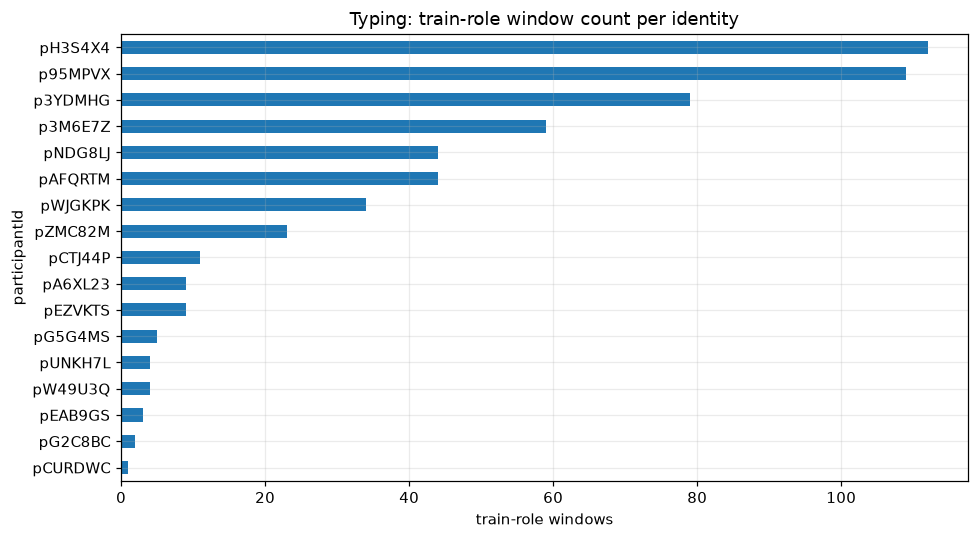

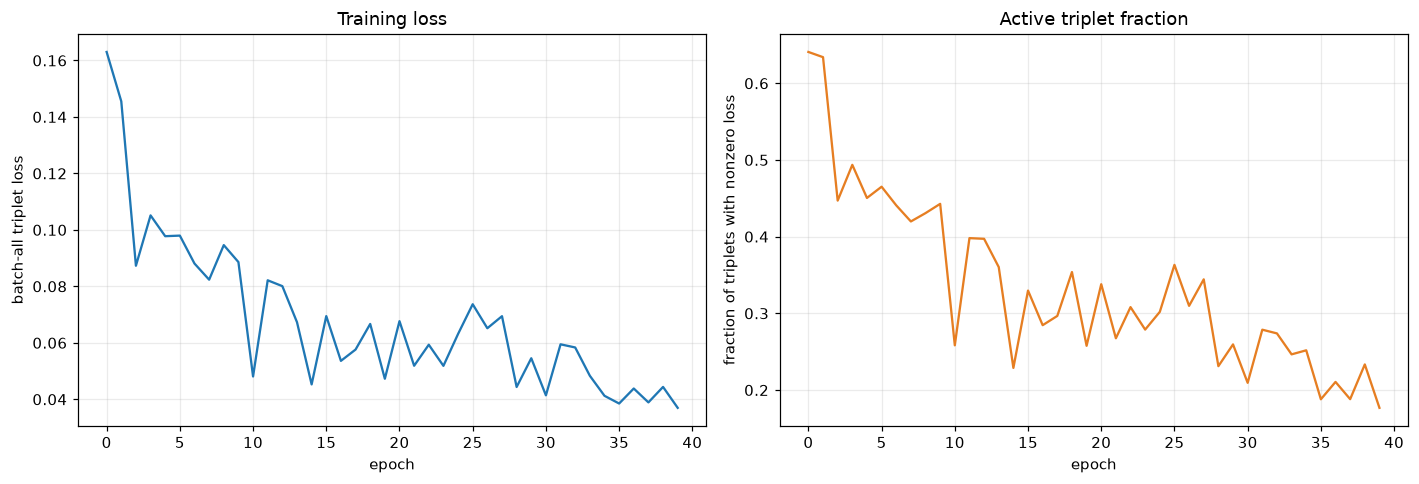

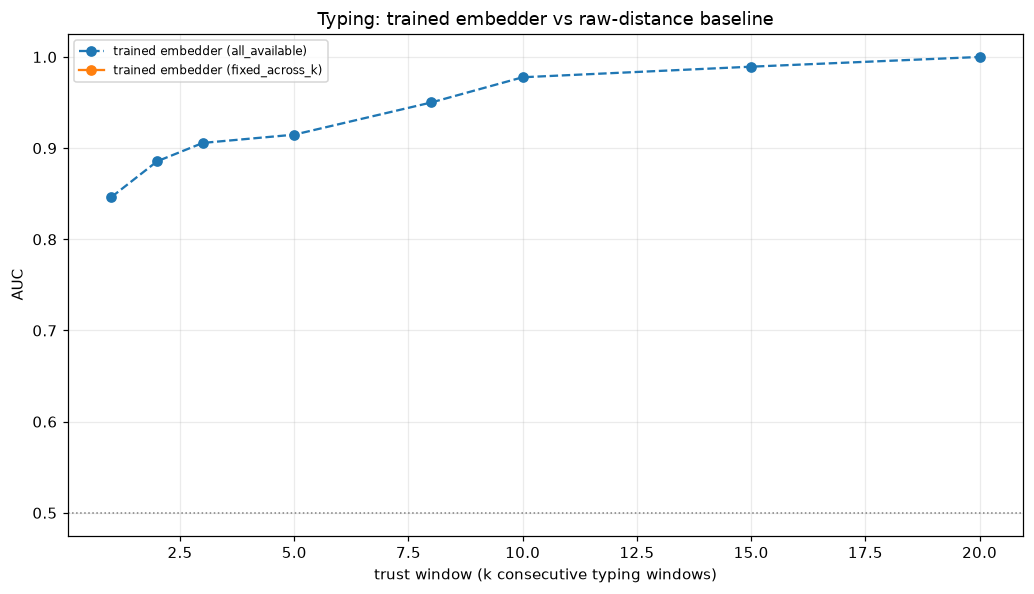

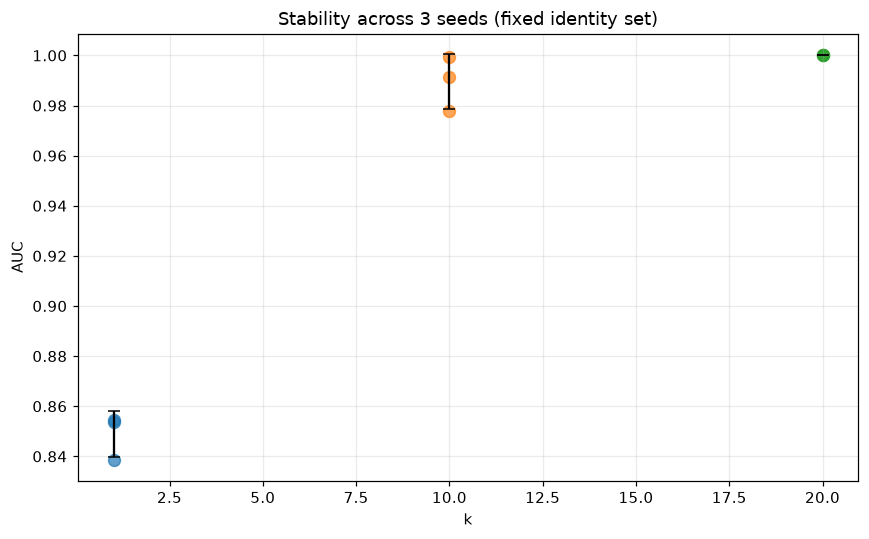

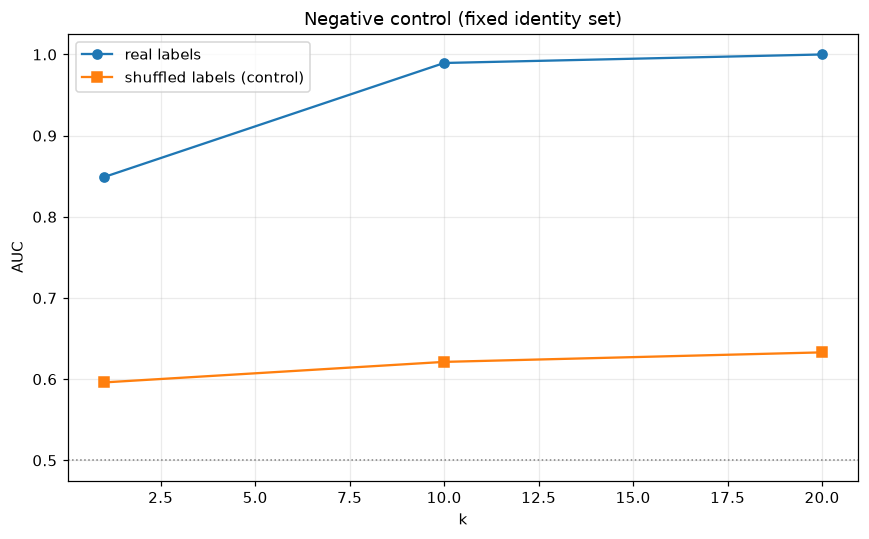

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary.index, summary['mean'], marker='o', label='real labels')
ax.plot(ctrl_summary.index, ctrl_summary['mean'], marker='s', label='shuffled labels (control)')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('k'); ax.set_ylabel('AUC'); ax.set_title('Negative control (fixed identity set)')
ax.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR / '05_negative_control.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Permutation feature importance

Same method as nb14: shuffle one feature at a time across probe windows,
recompute embeddings with the already-trained model, measure the AUC drop
at k=1 -- model-agnostic, no retraining needed.

In [14]:
rng = np.random.default_rng(0)
probe_mask = role_all == 'probe'
baseline_scored, _ = score_probe_windows(E_all, y_all, df_idx, role_all, [1])
baseline_res, _ = summarise(baseline_scored, fixed_identities=fixed_identities, label='fixed_across_k')
baseline_auc = baseline_res.loc[baseline_res['k']==1, 'auc'].iloc[0]
print(f"baseline (unpermuted) AUC at k=1: {baseline_auc:.3f}")

importances = []
X_perm_base = X_all.copy()
for j, feat_name in enumerate(feats):
    X_perm = X_perm_base.copy()
    perm_idx = rng.permutation(np.where(probe_mask)[0])
    X_perm[np.where(probe_mask)[0], j] = X_perm_base[perm_idx, j]
    E_perm = embed(model, X_perm)
    sc_perm, _ = score_probe_windows(E_perm, y_all, df_idx, role_all, [1])
    res_perm, _ = summarise(sc_perm, fixed_identities=fixed_identities, label='fixed_across_k')
    perm_auc = res_perm.loc[res_perm['k']==1, 'auc'].iloc[0] if len(res_perm) else np.nan
    importances.append({'feature': feat_name, 'auc_drop': baseline_auc - perm_auc})

importance_df = pd.DataFrame(importances).sort_values('auc_drop', ascending=False)
print(importance_df.head(15).to_string(index=False, float_format=lambda v: f'{v:.4f}'))

baseline (unpermuted) AUC at k=1: 0.854
                                        feature  auc_drop
         coupling_key_orient_gamma_peak_dev_max    0.0114
coupling_key_orient_gamma_peak_latency_ms_slope    0.0092
  coupling_key_orient_beta_peak_latency_ms_mean    0.0076
                     typing_dwell_letter_ms_std    0.0058
        coupling_key_orient_gamma_peak_dev_mean    0.0050
             coupling_key_accel_latency_ms_mean    0.0048
         coupling_key_orient_gamma_peak_dev_p95    0.0046
                      typing_dwell_letter_ms_cv    0.0042
                    coupling_key_accel_peak_iqr    0.0040
                     typing_transition_ms_slope    0.0026
         typing_transition_letter_letter_ms_p95    0.0021
         typing_transition_letter_letter_ms_max    0.0017
                             typing_share_enter    0.0015
                    typing_dwell_letter_ms_mean    0.0010
  coupling_key_orient_gamma_peak_latency_ms_p95    0.0007


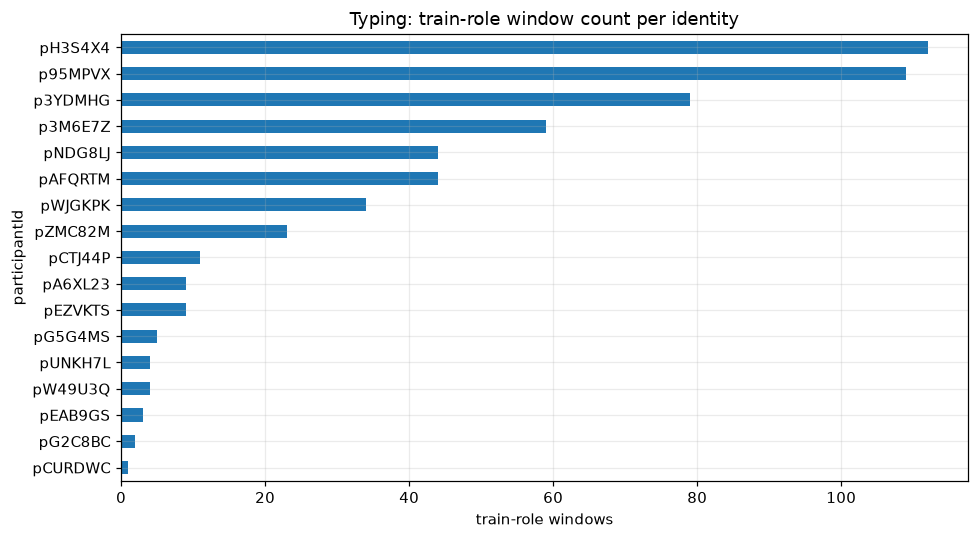

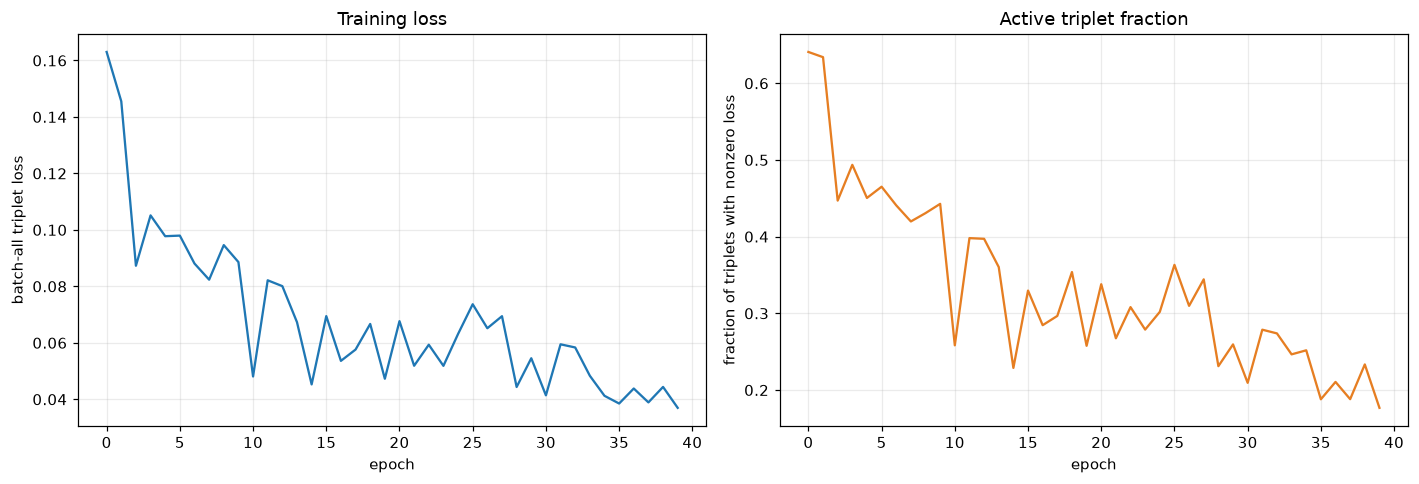

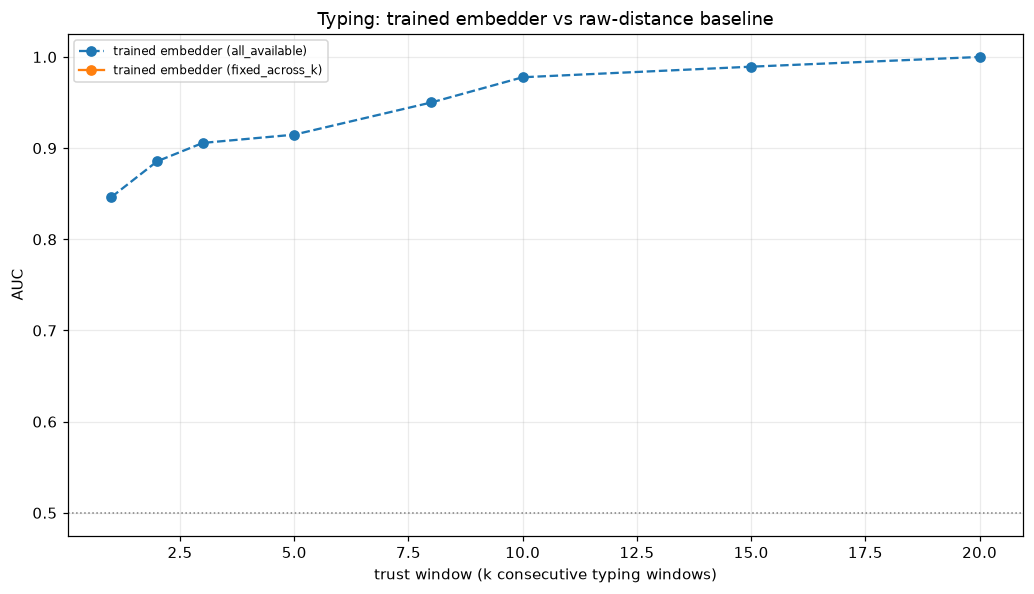

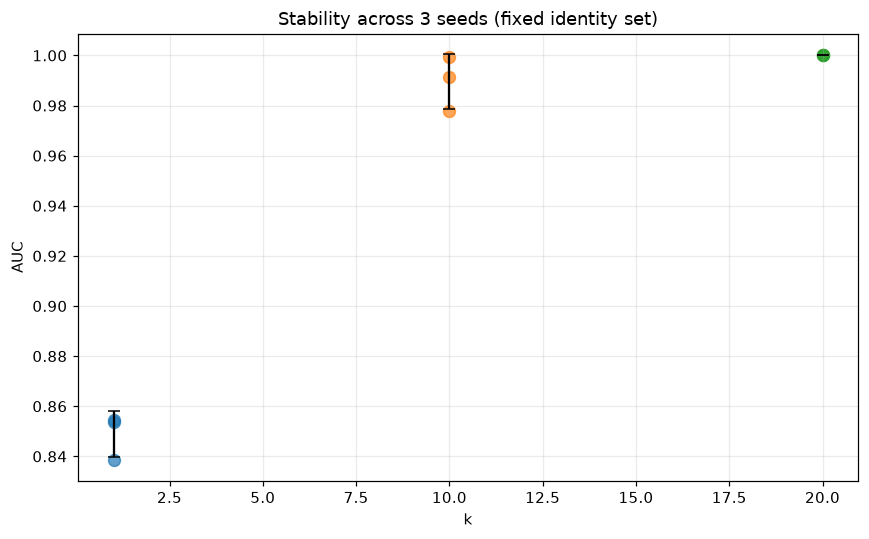

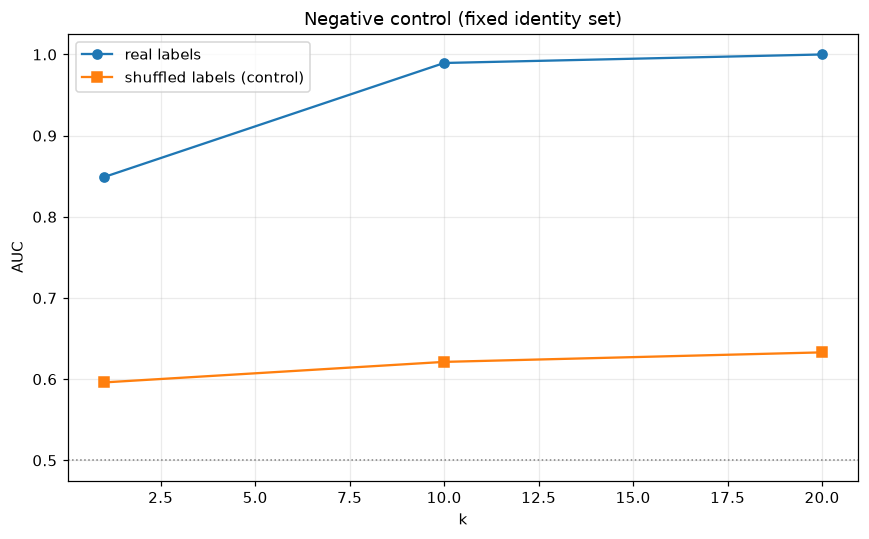

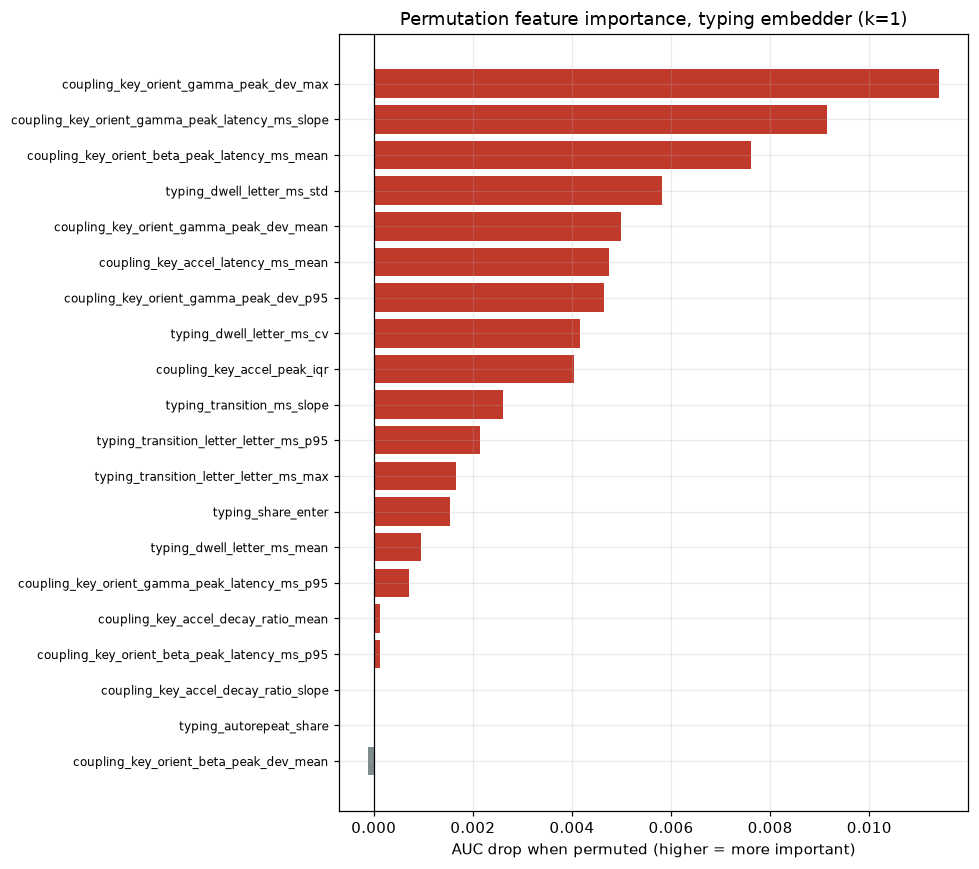


NOTE: 59 feature(s) show a NEGATIVE auc_drop (performance improved when permuted, i.e. removing their real signal helped) -- worth checking whether these are adding noise rather than signal, candidates for exclusion in a future feature-set pass.


In [15]:
fig, ax = plt.subplots(figsize=(9, 8))
top = importance_df.head(20).iloc[::-1]
ax.barh(range(len(top)), top['auc_drop'], color=['#c0392b' if v > 0 else '#7f8c8d' for v in top['auc_drop']])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top['feature'], fontsize=8)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('AUC drop when permuted (higher = more important)')
ax.set_title('Permutation feature importance, typing embedder (k=1)')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

n_negative = (importance_df['auc_drop'] < -0.005).sum()
if n_negative:
    print(f"\nNOTE: {n_negative} feature(s) show a NEGATIVE auc_drop (performance improved when "
          f"permuted, i.e. removing their real signal helped) -- worth checking whether these are "
          f"adding noise rather than signal, candidates for exclusion in a future feature-set pass.")


## 10. Embedding space, qualitatively

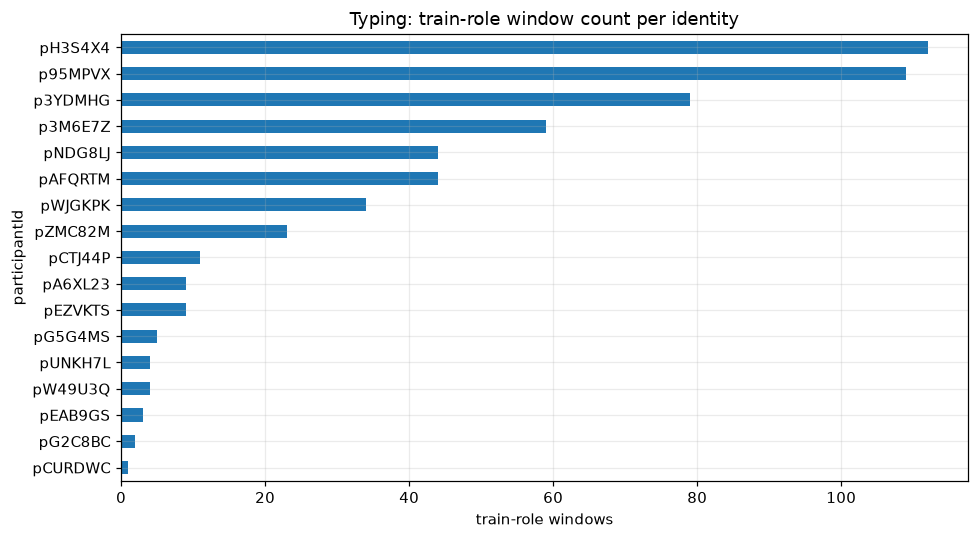

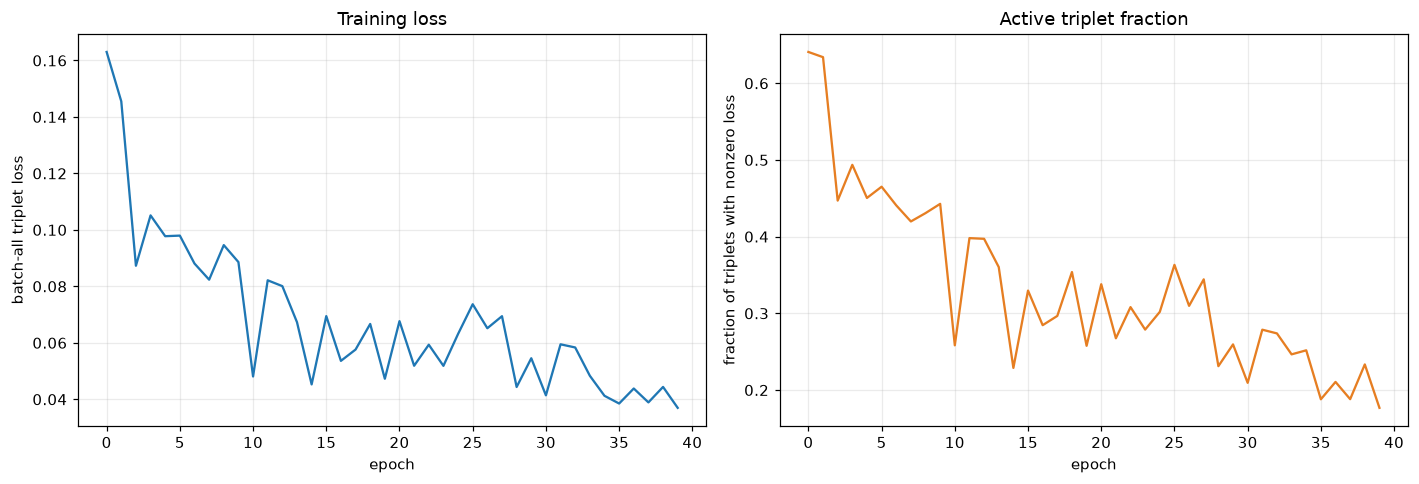

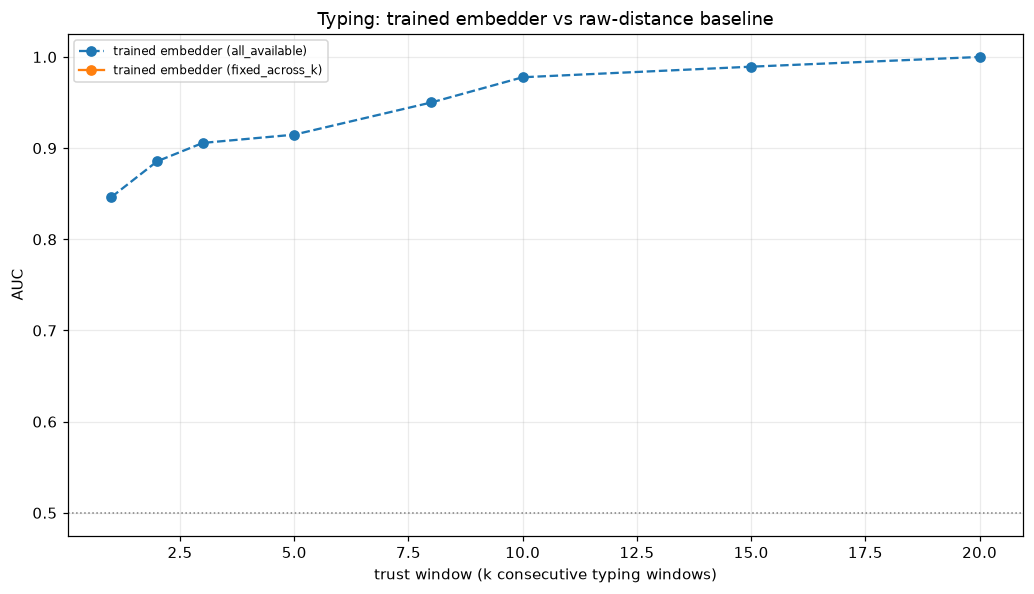

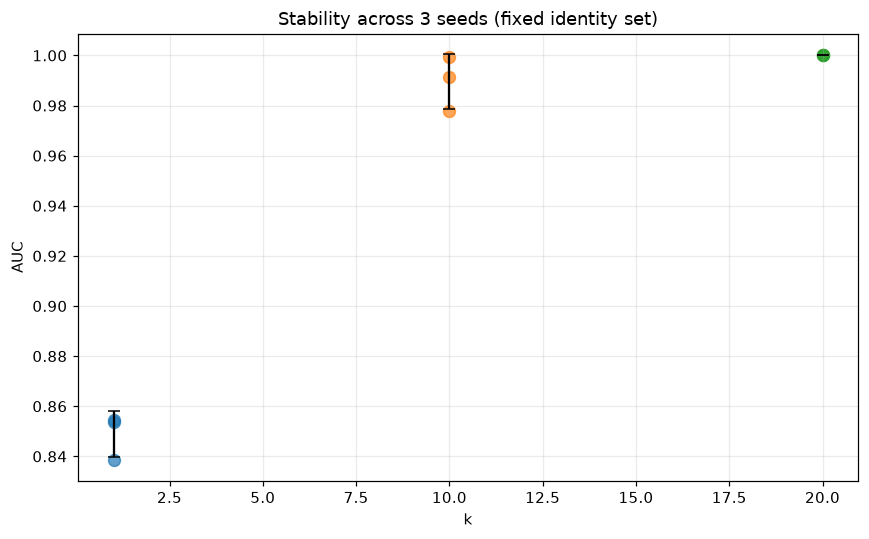

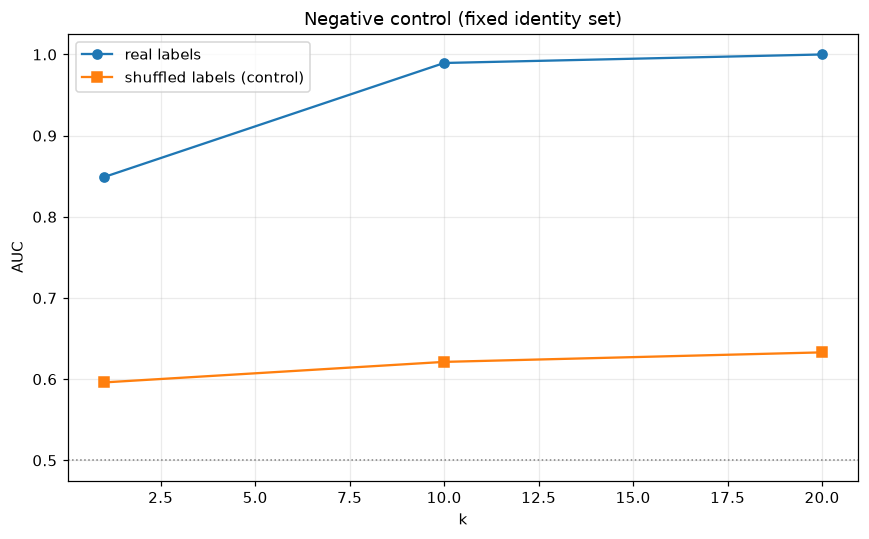

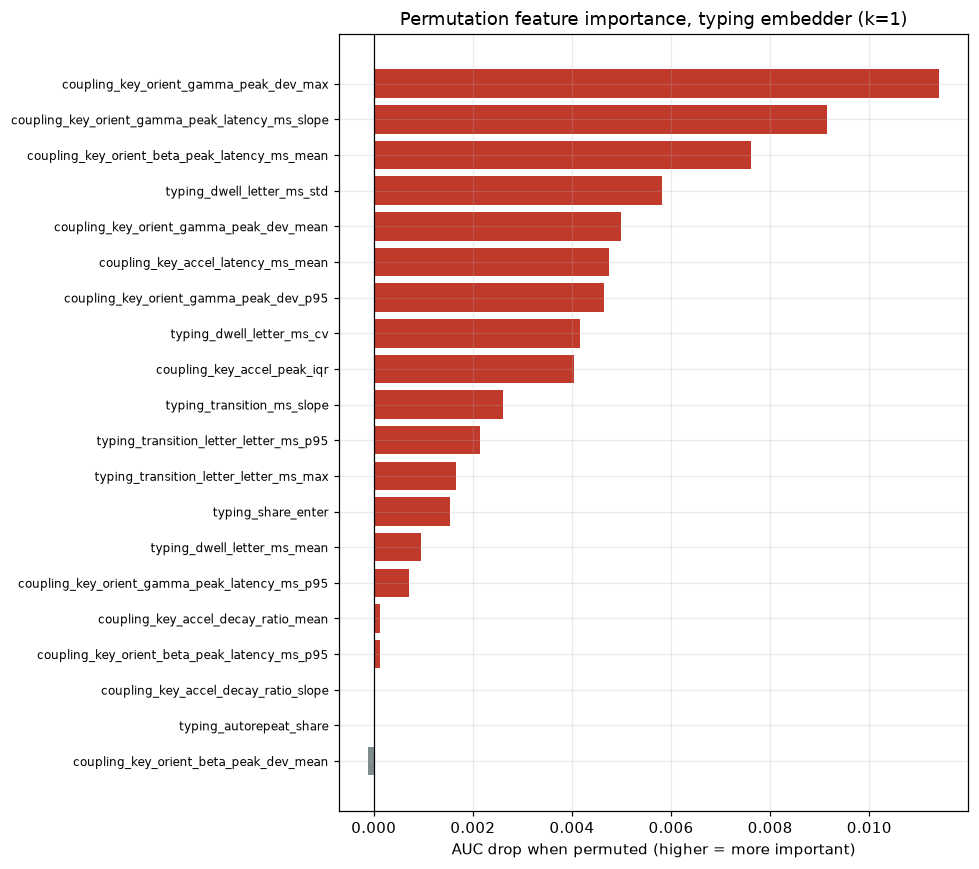

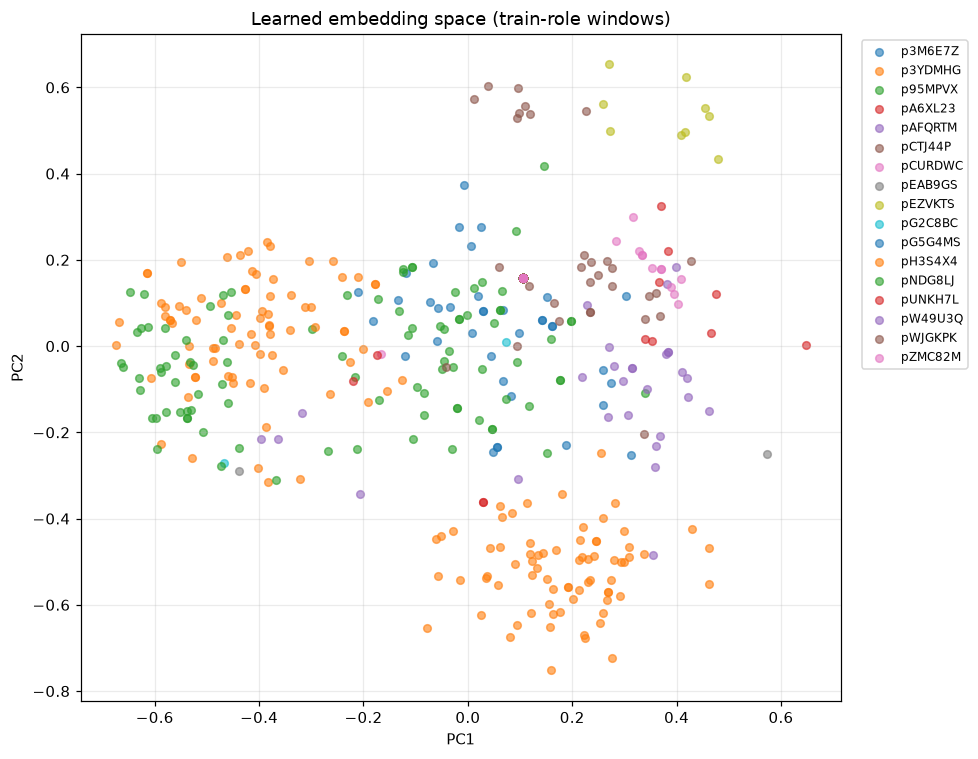

explained variance (first 2 PCs): [0.289 0.236]


In [16]:
with torch.no_grad():
    E_train = embed(model, X_all[role_all == 'train'])
y_train_plot = y_all[role_all == 'train']

pca = PCA(n_components=2).fit(E_train)
E2 = pca.transform(E_train)

fig, ax = plt.subplots(figsize=(9, 7))
for pid in np.unique(y_train_plot):
    m = y_train_plot == pid
    ax.scatter(E2[m, 0], E2[m, 1], label=pid, alpha=0.6, s=25)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Learned embedding space (train-role windows)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '06_embedding_space_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"explained variance (first 2 PCs): {pca.explained_variance_ratio_.round(3)}")

## 11. Export

In [17]:
import json as _json
from datetime import datetime, timezone

PREFIX = 'typing_'

res_df.to_csv(OUT_DIR / f'{PREFIX}trained_vs_baseline.csv', index=False)
per_id_df.to_csv(OUT_DIR / f'{PREFIX}per_participant.csv', index=False)
loo_df.to_csv(OUT_DIR / f'{PREFIX}leave_one_out.csv', index=False)
seed_df.to_csv(OUT_DIR / f'{PREFIX}seed_stability_raw.csv', index=False)
summary.reset_index().to_csv(OUT_DIR / f'{PREFIX}seed_stability_summary.csv', index=False)
control_df.to_csv(OUT_DIR / f'{PREFIX}negative_control_raw.csv', index=False)
compare.reset_index().to_csv(OUT_DIR / f'{PREFIX}negative_control_summary.csv', index=False)
history.to_csv(OUT_DIR / f'{PREFIX}training_history_seed42.csv', index=False)
importance_df.to_csv(OUT_DIR / f'{PREFIX}feature_importance.csv', index=False)

torch.save({'state_dict': model.state_dict(), 'feature_names': feats, 'embed_dim': EMBED_DIM},
           OUT_DIR / f'{PREFIX}model_seed42.pt')
np.savez(OUT_DIR / f'{PREFIX}preprocessing.npz', impute_values=imputer.statistics_,
         scale_mean=scaler.mean_, scale_scale=scaler.scale_,
         feature_names=np.array(feats, dtype=object))

manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'modality': 'typing', 'data_fingerprint': fp,
    'n_windows': int(len(df)), 'n_features': len(feats),
    'n_reference_identities': len(refs), 'n_fixed_identities': len(fixed_identities),
    'fixed_identities': sorted(fixed_identities),
    'architecture': '256-128-32 MLP, dropout 0.10, L2-normalised output',
    'max_batches_per_epoch': MAX_BATCHES_PER_EPOCH, 'epochs': EPOCHS, 'seeds_run': SEEDS,
    'baseline_source': 'trust_window_results.csv, typing/fixed_across_k/auc_cohort_norm (loaded dynamically)',
    'auc_real_fixed_at_k1_k10_k20': {int(k): round(float(v), 3) for k, v in summary['mean'].items()},
    'auc_shuffled_fixed_at_k1_k10_k20': {int(k): round(float(v), 3) for k, v in ctrl_summary['mean'].items()},
    'leave_one_out_at_k20': {str(k): round(float(v), 3) for k, v in loo.items()},
    'files': sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()) +
             ['plots/' + p.name for p in PLOTS_DIR.iterdir()],
}
with open(OUT_DIR / f'{PREFIX}manifest.json', 'w') as f:
    _json.dump(manifest, f, indent=2)

print(f"Wrote to {OUT_DIR.resolve()}:")
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f"  {p.relative_to(OUT_DIR)}  ({p.stat().st_size / 1024:.1f} KB)")


Wrote to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/typing_embedder:
  checkpoints/control0_454fe4b1b6ec8a5a.pt  (258.6 KB)
  checkpoints/control0_bc498d1cb88471b7.pt  (258.6 KB)
  checkpoints/control1_454fe4b1b6ec8a5a.pt  (258.6 KB)
  checkpoints/control1_bc498d1cb88471b7.pt  (258.6 KB)
  checkpoints/control2_454fe4b1b6ec8a5a.pt  (258.6 KB)
  checkpoints/control2_bc498d1cb88471b7.pt  (258.6 KB)
  checkpoints/control3_454fe4b1b6ec8a5a.pt  (258.6 KB)
  checkpoints/control3_bc498d1cb88471b7.pt  (258.6 KB)
  checkpoints/control4_454fe4b1b6ec8a5a.pt  (258.6 KB)
  checkpoints/control4_bc498d1cb88471b7.pt  (258.6 KB)
  checkpoints/control5_454fe4b1b6ec8a5a.pt  (258.6 KB)
  checkpoints/control5_bc498d1cb88471b7.pt  (258.6 KB)
  checkpoints/control6_454fe4b1b6ec8a5a.pt  (258.6 KB)
  checkpoints/control6_bc498d1cb88471b7.pt  (258.6 KB)
  checkpoints/control7_454fe4b1b6ec8a5a.pt  (258.6 KB)
  checkpoints/control7_bc498d1cb88471b7.pt  (258.6 KB)
  checkpoints/primary_seed42_45

## How to avoid the wait on repeat runs

Same guidance as nb14/nb15/nb16: don't Restart & Run All unless something
upstream changed; `FORCE_RETRAIN = False` reloads all trained models from
`checkpoints/` keyed on a data/feature/role fingerprint; lower
`MAX_BATCHES_PER_EPOCH` for a quick sanity check while iterating on
unrelated cells; Sections 7-8 are the majority of total trainings, so
comment out seeds/controls you don't need while iterating on something
else. Given typing's small size, training itself should be the fastest
of the four modalities regardless.
